In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 40)

SEED = 0
rng = np.random.default_rng(SEED)

# What gets reviewed together? Categories in the review data

`ttn_complementary.ipynb` trains against `also_buy` and a co-purchase table
built from reviews (`co_purchase_pairs_train.pkl`), each already filtered
through a category whitelist before the model ever sees them. This notebook
goes around both: straight from the raw review log, it asks what a reviewer
reviews **next** — no whitelist, no `also_buy`, no §19 same-category drop.

For every review, every OTHER item the same reviewer reviewed in the following
**N days** is a candidate "next item". Rolling that up to the category level
answers the question this project keeps returning to: is what people actually
do dominated by **substitutes** (another item from the same narrow category) or
**complements** (something from a different one)?

`N` is a parameter, not a fixed choice — change `WINDOW_DAYS` below and re-run
from that cell down.

## 1. Load reviews and item categories

In [2]:
# --- Reviews: reviewerID, asin, when ---------------------------------------
reviews = pd.read_csv(
    DATA_DIR / "Home_and_Kitchen_filtered.csv",
    usecols=["reviewerID", "asin", "unixReviewTime"],
    dtype={"reviewerID": str, "asin": str},
    low_memory=False,
)
reviews["t"] = pd.to_numeric(reviews["unixReviewTime"], errors="coerce")
reviews = reviews.dropna(subset=["t", "reviewerID", "asin"])
print(f"reviews: {len(reviews):,} rows, {reviews.reviewerID.nunique():,} reviewers, "
      f"{reviews.asin.nunique():,} asins")

# --- Item -> category path, one row per asin -------------------------------
# `Missing` matches the convention used throughout this project (e.g. cell 7 of
# ttn_complementary.ipynb) rather than leaving cat_4 as NaN.
item_cats = (pd.read_pickle(DATA_DIR / "df_features.pkl")[["asin", "cat_2", "cat_3", "cat_4"]]
             .drop_duplicates("asin"))
for c in ("cat_2", "cat_3", "cat_4"):
    item_cats[c] = item_cats[c].fillna("Missing").astype(str)
print(f"item categories: {len(item_cats):,} asins described")

reviews = reviews.merge(item_cats, on="asin", how="inner")
reviews = reviews.sort_values(["reviewerID", "t"]).reset_index(drop=True)
print(f"reviews with a known category: {len(reviews):,}")
print(f"distinct cat_2: {reviews.cat_2.nunique()}  "
      f"cat_3: {reviews.cat_3.nunique()}  cat_4: {reviews.cat_4.nunique()}")

reviews: 6,898,955 rows, 777,242 reviewers, 189,172 asins
item categories: 1,134,566 asins described
reviews with a known category: 5,764,886
distinct cat_2: 7  cat_3: 69  cat_4: 456


## 2. Parameters

`WINDOW_DAYS` is the one built to be changed. `MAX_FOLLOWUPS_PER_REVIEW` exists because a handful of very active reviewers would otherwise dominate every category-pair count — capping (with random sampling beyond the cap) keeps one prolific account from outweighing thousands of ordinary ones.

In [3]:
# --- The one thing you're likely to change: the follow-up window ----------
WINDOW_DAYS = 90          # "next N days" -- change this and re-run from here

# A user's review stream can be long, and a handful of very active reviewers
# would otherwise dominate every category-pair count. Each SOURCE review keeps
# at most this many of its in-window follow-ups, sampled uniformly when there
# are more; the rest of the analysis is unaffected by how prolific one
# reviewer happens to be.
MAX_FOLLOWUPS_PER_REVIEW = 15

TOP_K = 5                 # top-K destination categories per source, in the table
TOP_SOURCES_FOR_CHART = 15   # how many source categories the chart shows

## 3. Every "reviewed within N days" pair

Directed and forward-only: a pair exists from review A to review B only when B
came after A, within the window. A reviewer's own re-review of the SAME asin
(a duplicate record, or genuinely reviewing it twice) is excluded — it is not a
*next item*, it is the same item again.

Built with `searchsorted` per reviewer rather than a row-by-row loop: for
~776,000 reviewers this runs in a few seconds regardless of `WINDOW_DAYS`.

In [4]:
def build_next_n_day_pairs(reviews, window_days, max_followups, seed=0):
    """For every review, every OTHER item the same reviewer reviewed in the
    following `window_days` days -- directed, forward in time only.

    `reviews` must already be sorted by (reviewerID, t). Runs in two passes per
    reviewer's block, using `searchsorted` on that block's own timestamps to
    find each review's window boundary -- no Python-level loop over rows, only
    over reviewers (~776k of them, a few seconds total).
    """
    rid = reviews["reviewerID"].to_numpy()
    asin = reviews["asin"].to_numpy()
    times = reviews["t"].to_numpy()
    n = len(reviews)
    change = np.flatnonzero(rid[1:] != rid[:-1]) + 1
    starts = np.concatenate([[0], change, [n]])
    window_seconds = window_days * 86400
    local_rng = np.random.default_rng(seed)

    src_chunks, tgt_chunks = [], []
    for g in range(len(starts) - 1):
        s, e = starts[g], starts[g + 1]
        m = e - s
        if m < 2:
            continue
        tt = times[s:e]
        upper = np.searchsorted(tt, tt + window_seconds, side="right")
        for i in range(m - 1):
            j_max = upper[i]
            if j_max <= i + 1:
                continue
            cand = np.arange(i + 1, j_max)
            if len(cand) > max_followups:
                cand = local_rng.choice(cand, max_followups, replace=False)
            src_chunks.append(np.full(len(cand), s + i))
            tgt_chunks.append(s + cand)

    src_idx = np.concatenate(src_chunks)
    tgt_idx = np.concatenate(tgt_chunks)
    # A user re-reviewing (or a duplicate record of) the SAME asin is not a
    # "next item" -- it is the same item again. Excluded so every pair below
    # describes two genuinely different products.
    keep = asin[src_idx] != asin[tgt_idx]
    return src_idx[keep], tgt_idx[keep]


src_idx, tgt_idx = build_next_n_day_pairs(reviews, WINDOW_DAYS, MAX_FOLLOWUPS_PER_REVIEW, SEED)
deltas_days = (reviews["t"].to_numpy()[tgt_idx] - reviews["t"].to_numpy()[src_idx]) / 86400
print(f"next-{WINDOW_DAYS}-day pairs: {len(src_idx):,}")
print(f"days between review and follow-up: median {np.median(deltas_days):.1f}, "
      f"p90 {np.percentile(deltas_days, 90):.0f}, max {deltas_days.max():.0f}")

next-90-day pairs: 9,614,665
days between review and follow-up: median 2.0, p90 68, max 90


## 4. Top 5 destination categories per source — long format

One row per (source category, rank). `rank` 1 is that source's most common
next-category; `share` is its fraction of that source's next-N-day reviews, so
the five rows per source sum to at most 1.0 (the remainder is everything
outside the top 5).

In [5]:
# --- Every pair's category path on both sides ------------------------------
_c2, _c3, _c4 = reviews["cat_2"].to_numpy(), reviews["cat_3"].to_numpy(), reviews["cat_4"].to_numpy()
edges = pd.DataFrame({
    "src_cat_2": _c2[src_idx], "src_cat_3": _c3[src_idx], "src_cat_4": _c4[src_idx],
    "dst_cat_2": _c2[tgt_idx], "dst_cat_3": _c3[tgt_idx], "dst_cat_4": _c4[tgt_idx],
})
SRC_COLS = ["src_cat_2", "src_cat_3", "src_cat_4"]
DST_COLS = ["dst_cat_2", "dst_cat_3", "dst_cat_4"]

pair_counts = edges.value_counts(SRC_COLS + DST_COLS).rename("edges").reset_index()
src_total = pair_counts.groupby(SRC_COLS)["edges"].transform("sum")
pair_counts["share"] = pair_counts["edges"] / src_total
pair_counts["rank"] = (pair_counts.groupby(SRC_COLS)["share"]
                       .rank(ascending=False, method="first").astype(int))

print(f"distinct source categories (full cat_2>cat_3>cat_4 path): "
      f"{pair_counts.groupby(SRC_COLS).ngroups:,}")
print(f"distinct (source, destination) category pairs: {len(pair_counts):,}")

# --- The long-format table asked for: one row per (source, rank) ----------
top_categories = (pair_counts[pair_counts["rank"] <= TOP_K]
                  .sort_values(SRC_COLS + ["rank"])
                  [SRC_COLS + ["rank"] + DST_COLS + ["edges", "share"]]
                  .reset_index(drop=True))
print(f"\ntop-{TOP_K} long table: {len(top_categories):,} rows over "
      f"{top_categories.groupby(SRC_COLS).ngroups:,} source categories")
top_categories.head(TOP_K)

distinct source categories (full cat_2>cat_3>cat_4 path): 533
distinct (source, destination) category pairs: 156,395

top-5 long table: 2,635 rows over 533 source categories


,src_cat_2,src_cat_3,src_cat_4,rank,dst_cat_2,dst_cat_3,dst_cat_4,edges,share
0,Bath,Bath Rugs,Missing,1,Bath,Bathroom Accessories,"Shower Curtains, Hooks & Liners",2959,0.061285
1,Bath,Bath Rugs,Missing,2,Bath,Bath Rugs,Missing,1536,0.031812
2,Bath,Bath Rugs,Missing,3,Home Dcor,"Area Rugs, Runners & Pads",Area Rugs,1383,0.028644
3,Bath,Bath Rugs,Missing,4,Home Dcor,Window Treatments,Draperies & Curtains,1136,0.023528
4,Bath,Bath Rugs,Missing,5,Bath,Bathroom Accessories,Holders & Dispensers,955,0.019779


## 5. Complements or substitutes — the blunt number

Same category at every level looks like a substitute (another item from the
identical narrow slot); a different `cat_2` entirely looks like a genuine
complement. The two intermediate cases — same broad department but a different
sub-category — are the interesting middle ground this question usually turns
on.

In [6]:
# --- Complements or substitutes? A first, blunt answer ---------------------
same_node = ((edges.src_cat_2 == edges.dst_cat_2) & (edges.src_cat_3 == edges.dst_cat_3)
            & (edges.src_cat_4 == edges.dst_cat_4))
same_cat3 = (edges.src_cat_2 == edges.dst_cat_2) & (edges.src_cat_3 == edges.dst_cat_3)
same_cat2 = edges.src_cat_2 == edges.dst_cat_2

print(f"of {len(edges):,} next-{WINDOW_DAYS}-day pairs, excluding the same asin reviewed twice:")
print(f"  identical category (cat_2, cat_3 & cat_4) -- likely SUBSTITUTES : {same_node.mean():.1%}")
print(f"  same cat_3, different cat_4                                    : {(same_cat3 & ~same_node).mean():.1%}")
print(f"  same cat_2, different cat_3                                    : {(same_cat2 & ~same_cat3).mean():.1%}")
print(f"  different cat_2 entirely -- likely genuine COMPLEMENTS         : {(~same_cat2).mean():.1%}")
print(f"\nfor comparison, on also_buy (notebooks/also_buy_popularity.ipynb): "
      f"same cat_4 54.8%, and on this project's own co_purchase_pairs_train.pkl "
      f"(ttn/experiments/): same cat_4 ~5-8%, same cat_2 ~56-71% depending on the slice.")
print("\nMost co-reviewed pairs share a broad department (cat_2) but land in a")
print("DIFFERENT sub-category -- more consistent with buying several different")
print("things for the same room or project than with comparison shopping.")

of 9,614,665 next-90-day pairs, excluding the same asin reviewed twice:
  identical category (cat_2, cat_3 & cat_4) -- likely SUBSTITUTES : 8.1%
  same cat_3, different cat_4                                    : 9.5%
  same cat_2, different cat_3                                    : 38.2%
  different cat_2 entirely -- likely genuine COMPLEMENTS         : 44.2%

for comparison, on also_buy (notebooks/also_buy_popularity.ipynb): same cat_4 54.8%, and on this project's own co_purchase_pairs_train.pkl (ttn/experiments/): same cat_4 ~5-8%, same cat_2 ~56-71% depending on the slice.

Most co-reviewed pairs share a broad department (cat_2) but land in a
DIFFERENT sub-category -- more consistent with buying several different
things for the same room or project than with comparison shopping.


## 6. The same picture, visualized at the cat_3 level

One bar per source category (`cat_2 > cat_3`), 100% stacked by share of its
next-N-day reviews. Colour encodes **rank position** (1st most common,
2nd, ...), not a fixed category — each source's own top 5 are different
categories, so there is no single 5-colour legend that means the same thing on
every bar. Segments wide enough to hold text are labelled directly; the table
in §4 has the rest.

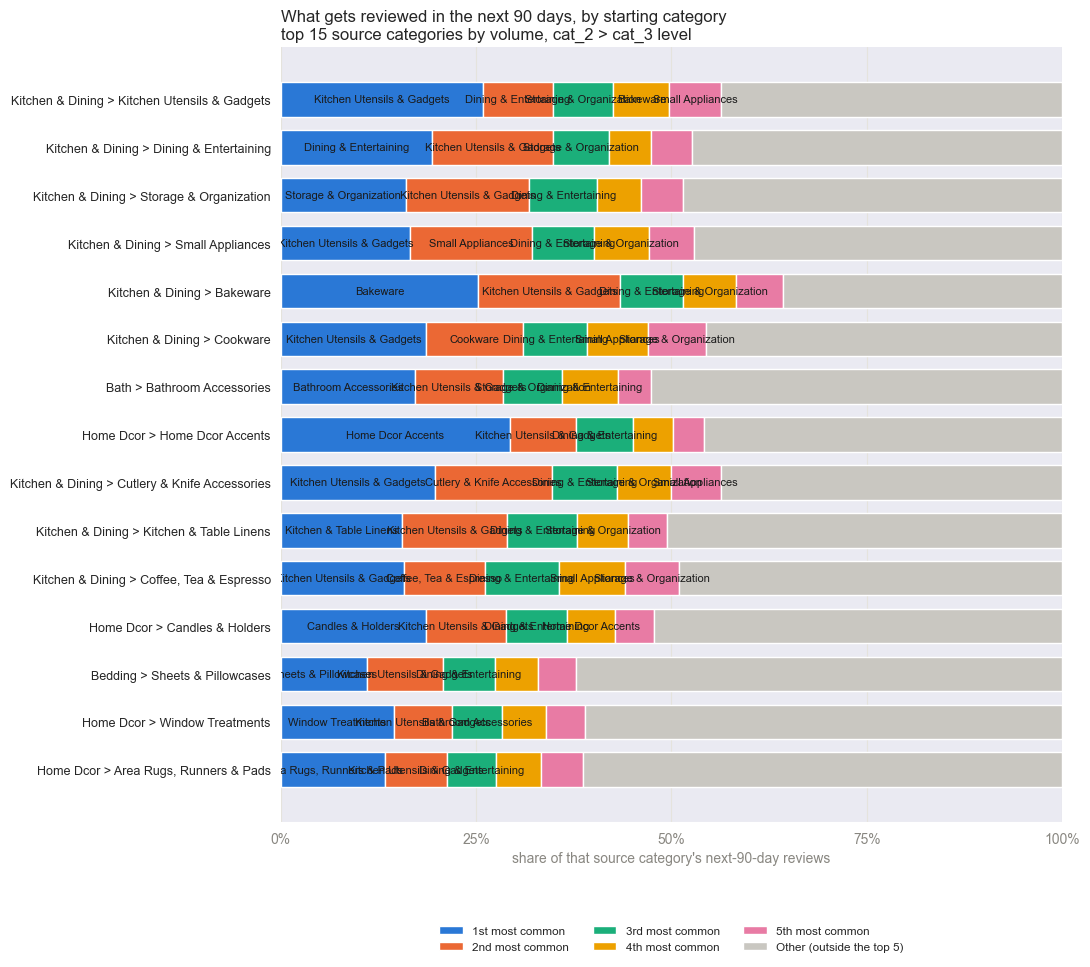

In [7]:
# --- The same picture, rolled up to cat_3 and shown as shares --------------
# Colour here encodes RANK (this source's #1, #2, ... most common destination),
# not a fixed category -- with each source category free to co-occur with a
# different set of destinations, there is no single palette of ~5 categories
# shared across every bar. The legend says "1st / 2nd / ... most common", and
# each segment wide enough to hold text is labelled directly with which
# category it actually is; `top_categories` above has the rest.
_L3, _L2 = "cat_3_label", "cat_2"
c3 = edges.assign(
    src_label=edges.src_cat_2 + " > " + edges.src_cat_3,
    dst_label=edges.dst_cat_2 + " > " + edges.dst_cat_3,
)
c3_counts = c3.value_counts(["src_label", "dst_label"]).rename("edges").reset_index()
src_tot3 = c3_counts.groupby("src_label")["edges"].transform("sum")
c3_counts["share"] = c3_counts["edges"] / src_tot3

top_sources = (c3_counts.groupby("src_label")["edges"].sum()
              .nlargest(TOP_SOURCES_FOR_CHART).index.tolist())

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]   # ranks 1-5, fixed order
OTHER_COLOR = "#c9c7c1"
TEXT_ON_SEGMENT = "#1a1a1a"        # verified higher-contrast than white on every slot above
INK_MUTED = "#898781"              # this palette's axis/label token

fig, ax = plt.subplots(figsize=(11, 0.55 * len(top_sources) + 1.5))
y_pos = np.arange(len(top_sources))[::-1]     # biggest source at the top

for y, src in zip(y_pos, top_sources):
    row = c3_counts[c3_counts.src_label == src].sort_values("share", ascending=False)
    top5 = row.head(TOP_K)
    other_share = 1.0 - top5["share"].sum()
    left = 0.0
    for rank, (_, r) in enumerate(top5.iterrows()):
        w = r["share"]
        ax.barh(y, w, left=left, height=0.72, color=PALETTE[rank], edgecolor="white", linewidth=1)
        if w >= 0.06:       # only label what fits without crowding
            label = r["dst_label"].split(" > ")[-1]
            ax.text(left + w / 2, y, label, ha="center", va="center",
                    fontsize=8, color=TEXT_ON_SEGMENT, clip_on=True)
        left += w
    if other_share > 0:
        ax.barh(y, other_share, left=left, height=0.72, color=OTHER_COLOR, edgecolor="white", linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_sources, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], color=INK_MUTED)
ax.set_xlabel(f"share of that source category's next-{WINDOW_DAYS}-day reviews", color=INK_MUTED)
ax.set_title(f"What gets reviewed in the next {WINDOW_DAYS} days, by starting category\n"
            f"top {TOP_SOURCES_FOR_CHART} source categories by volume, cat_2 > cat_3 level",
            fontsize=12, loc="left")
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis="x", color="#e5e3dd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
handles = [Patch(facecolor=PALETTE[i], label=f"{i+1}{'st' if i==0 else 'nd' if i==1 else 'rd' if i==2 else 'th'} most common")
          for i in range(TOP_K)] + [Patch(facecolor=OTHER_COLOR, label="Other (outside the top 5)")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12),
         ncol=3, frameon=False, fontsize=8.5)

plt.tight_layout()
plt.show()

## 7. One category at a time, on demand

Same chart, same colours, same rank-based legend as §6 — just for a single
`(cat_2, cat_3)` you choose instead of the top 15 by volume. Change
`INPUT_CAT_2` / `INPUT_CAT_3` below and re-run the cell; it reuses `c3_counts`
from §6, so it costs nothing to try several categories.

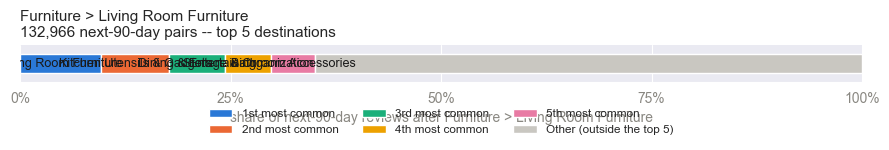


top 5 destinations for Furniture > Living Room Furniture (132,966 pairs):
                                    dst_label  edges  share
            Furniture > Living Room Furniture  12741   9.6%
Kitchen & Dining > Kitchen Utensils & Gadgets  10759   8.1%
     Kitchen & Dining > Dining & Entertaining   8897   6.7%
    Kitchen & Dining > Storage & Organization   7263   5.5%
                  Bath > Bathroom Accessories   6854   5.2%


In [10]:
def chart_for_category(cat_2, cat_3, top_k=TOP_K, figsize=(9, 2.2)):
    """The same chart as §6, for exactly one (cat_2, cat_3) you choose.

    Reuses `c3_counts` from the cell above rather than recomputing anything, so
    this is instant and always matches the current WINDOW_DAYS.
    """
    label = f"{cat_2} > {cat_3}"
    row = c3_counts[c3_counts.src_label == label].sort_values("share", ascending=False)
    if row.empty:
        print(f"{label!r} has no next-{WINDOW_DAYS}-day follow-up reviews in this data "
              f"-- check the spelling/casing against reviews['cat_2'].unique() / "
              f"reviews['cat_3'].unique(), or it may simply have too little review volume.")
        return

    total_edges = int(row["edges"].sum())
    top = row.head(top_k)
    other_share = max(0.0, 1.0 - top["share"].sum())

    fig, ax = plt.subplots(figsize=figsize)
    left = 0.0
    for rank, r in enumerate(top.itertuples(index=False)):
        w = r.share
        ax.barh(0, w, left=left, height=0.6, color=PALETTE[rank], edgecolor="white", linewidth=1)
        if w >= 0.05:
            ax.text(left + w / 2, 0, r.dst_label.split(" > ")[-1], ha="center", va="center",
                    fontsize=9, color=TEXT_ON_SEGMENT, clip_on=True)
        left += w
    if other_share > 0:
        ax.barh(0, other_share, left=left, height=0.6, color=OTHER_COLOR, edgecolor="white", linewidth=1)

    ax.set_xlim(0, 1); ax.set_ylim(-0.6, 0.6); ax.set_yticks([])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], color=INK_MUTED)
    ax.set_xlabel(f"share of next-{WINDOW_DAYS}-day reviews after {label}", color=INK_MUTED)
    ax.set_title(f"{label}\n{total_edges:,} next-{WINDOW_DAYS}-day pairs -- top {top_k} destinations",
                fontsize=11, loc="left")
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)

    from matplotlib.patches import Patch
    ordinals = ["1st", "2nd", "3rd"] + [f"{i}th" for i in range(4, top_k + 1)]
    handles = [Patch(facecolor=PALETTE[i], label=f"{ordinals[i]} most common") for i in range(top_k)]
    handles.append(Patch(facecolor=OTHER_COLOR, label="Other (outside the top " + str(top_k) + ")"))
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.45),
             ncol=3, frameon=False, fontsize=8.5)
    plt.tight_layout()
    plt.show()

    print(f"\ntop {top_k} destinations for {label} ({total_edges:,} pairs):")
    print(top[["dst_label", "edges", "share"]]
          .to_string(index=False, float_format=lambda x: f"{x:.1%}" if x < 1 else f"{x:.0f}"))


# --- Change these two and re-run this cell -- the chart updates -----------
INPUT_CAT_2 = "Furniture"
INPUT_CAT_3 = "Living Room Furniture"
chart_for_category(INPUT_CAT_2, INPUT_CAT_3)